<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Validation Legacy Peanuts 1: Vacuum 
---

This notebook validates Torch version `TPeanuts` vacuum neutrino-oscillation probabilities and vacuum-propagated spectra against the Legacy Numpy/Numba reference implementation of peanuts in `peanuts.vacuum.Pvacuum`. It establishes the baseline numerical precision of the package and verifies the exact three-flavour transition-probability formula over a grid of sample baselines and energies.

## Table of Contents

| § | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** — vacuum oscillation formula, PMNS parametrisation, oscillation lengths, validation strategy |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** — notebook paths, physical parameters |
| [3](#3.-Vacuum-Oscillation-Probability-Validation) | **Vacuum Oscillation Probability Validation** — grid comparison at sample (E, L) points |
| [4](#4.-Energy-Scan-Visualisation) | **Energy Scan Visualisation** — P(E) curves at L = 1300 km |
| [5](#5.-Precision-Mode-Diagnostic) | **Precision Mode Diagnostic** — full vs legacy precision comparison |
| [6](#6.-Vacuum-Flux-Propagation) | **Vacuum Flux Propagation** — synthetic atmospheric-like flux through vacuum |
| [7](#7.-Export-Results) | **Export Results** |
| [8](#8.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Three-Flavour Vacuum Oscillation Formula

In vacuum, neutrino flavour conversion is driven entirely by the quantum-mechanical interference of mass eigenstates accumulated during free propagation. For a neutrino produced as flavour $\nu_\alpha$ and detected as $\nu_\beta$ after travelling a distance $L$ at energy $E$, the exact transition probability is *(Pontecorvo 1957; Maki, Nakagawa & Sakata 1962)*

$$
P(\nu_\alpha \to \nu_\beta;\ L, E) = \left|\sum_{i=1}^{3} U_{\beta i}^{}\,\exp\!\left(-i\frac{m_i^2\,L}{2E}\right) U_{\alpha i}^*\right|^2.
$$

Expanding the modulus squared gives the standard interference form:

$$
P(\nu_\alpha \to \nu_\beta) = \delta_{\alpha\beta}
- 4\sum_{i>j} \mathrm{Re}\!\left[U_{\alpha i}^* U_{\beta i}\, U_{\alpha j}\, U_{\beta j}^*\right]
  \sin^2\!\left(\frac{\Delta m^2_{ij}\,L}{4E}\right)
+ 2\sum_{i>j} \mathrm{Im}\!\left[U_{\alpha i}^* U_{\beta i}\, U_{\alpha j}\, U_{\beta j}^*\right]
  \sin\!\left(\frac{\Delta m^2_{ij}\,L}{2E}\right),
$$

where $\Delta m^2_{ij} = m_i^2 - m_j^2$. The imaginary term is non-zero only for $\alpha \neq \beta$ and produces a $CP$ asymmetry when $\delta_{CP} \neq 0$. For three active flavours there are two independent mass splittings: $\Delta m^2_{21}$ (solar splitting) and $\Delta m^2_{31}$ (atmospheric splitting, sign encoding the mass ordering).

The imaginary combination of PMNS elements defines the **Jarlskog invariant** $J_{CP}$ *(Jarlskog 1985)*:

$$J_{CP} = \mathrm{Im}\!\left[U_{e1}^* U_{\mu 2}^{} U_{e2}^{} U_{\mu 1}^*\right]
= \frac{1}{8}\sin 2\theta_{12}\,\sin 2\theta_{13}\,\sin 2\theta_{23}\,\cos\theta_{13}\,\sin\delta_{CP}.$$

---

### 0.2 Standard PMNS Parametrisation

The PMNS matrix is conventionally factored into three Euler-type rotations and a diagonal $CP$-phase matrix *(PDG 2024)*:

$$U = R_{23}\,\Delta(\delta_{CP})\,R_{13}\,\Delta^\dagger(\delta_{CP})\,R_{12},$$

where $R_{ij}$ is a real rotation by $\theta_{ij}$ in the $(i,j)$ subspace and $\Delta(\delta_{CP}) = \mathrm{diag}(1,1,e^{i\delta_{CP}})$. The current best-fit values from the NuFIT 5.2 global analysis *(Esteban et al. 2022)*:

| Parameter | NuFIT 5.2 (NO) | Description |
|-----------|:--------------:|-------------|
| $\sin^2\theta_{12}$ | $0.303$ | Solar mixing angle |
| $\sin^2\theta_{13}$ | $0.02225$ | Reactor mixing angle |
| $\sin^2\theta_{23}$ | $0.572$ | Atmospheric mixing angle |
| $\delta_{CP}$ | $197°$ | $CP$-violating phase |
| $\Delta m^2_{21}$ | $7.41\times10^{-5}$ eV² | Solar mass splitting |
| $\Delta m^2_{31}$ | $2.511\times10^{-3}$ eV² | Atmospheric mass splitting (NO) |

---

### 0.3 Vacuum Oscillation Lengths

The argument of each sinusoidal term defines a **vacuum oscillation length**:

$$L_{ij}^{\rm osc}(E) = \frac{4\pi E}{\Delta m^2_{ij}} \approx 2.48\,\mathrm{km}\cdot\frac{E\,[\mathrm{GeV}]}{\Delta m^2_{ij}\,[\mathrm{eV}^2]}.$$

- For the solar splitting $\Delta m^2_{21}\approx 7.4\times10^{-5}$ $eV^2$, $L_{21}^{\rm osc}(1\,\mathrm{GeV})\approx 33{,}000$ km.
- For the atmospheric splitting $|\Delta m^2_{31}|\approx 2.5\times10^{-3}$ $eV^2$, $L_{31}^{\rm osc}(1\,\mathrm{GeV})\approx 990$ km, matching the DUNE and NOvA baselines.

The four sample baselines (T2K 295 km, NOvA 735 km, DUNE 1300 km, Earth diameter 12 000 km) probe different oscillation phases for each splitting.

---

### 0.4 Incoherent Vacuum Flux Propagation

For diffuse fluxes (e.g. atmospheric neutrinos), the source is a spectral mixture $\Phi_\beta(E)$. The propagated detector flux is:

$$\Phi_\alpha^{\rm det}(E) = \sum_\beta P(\nu_\beta \to \nu_\alpha;\ L, E)\,\Phi_\beta(E).$$

In TPeanuts this is handled by `vacuum_flux_state`, which applies `vacuum_probability_transition` element-wise. Section 6 validates this function against its legacy counterpart using a synthetic atmospheric-like spectrum.

---

### 0.5 Validation Strategy

Both `vacuum_probability_transition` and `peanuts.vacuum.Pvacuum` implement the same three-flavour formula with the same PMNS parameters. The expectation is therefore numerical agreement at **floating-point precision** ($\sim10^{-12}$ for double precision). Any visible structure in the relative error arises only from near-zero denominators, not from a different physical approximation.

The precision-mode diagnostic (Section 5) is included for API consistency with the matter-propagation notebooks. In vacuum there is no matter-potential prefactor, so `legacy_precision=True` does not change the Hamiltonian and both precision modes must give identical results.

---

**References**

- Pontecorvo, B. (1957). *Mesonium and antimesonium*. Zh. Eksp. Teor. Fiz. **33**, 549.
- Maki, Z., Nakagawa, M. & Sakata, S. (1962). *Remarks on the unified model of elementary particles*. Prog. Theor. Phys. **28**, 870.
- Jarlskog, C. (1985). *Commutator of the quark mass matrices in the standard electroweak model and a measure of maximal CP nonconservation*. Phys. Rev. Lett. **55**, 1039.
- Esteban, I., Gonzalez-Garcia, M. C., Maltoni, M., Schwetz, T. & Zhou, A. (NuFIT 5.2, 2022). *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*. JHEP **09**, 178.
- Particle Data Group (2024). *Review of Particle Physics*. Phys. Rev. D **110**, 030001.

## 1. Libraries


In [10]:
from __future__ import annotations

import math

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_COLORS,
    FLAVOUR_INDEX,
    FLAVOUR_LABELS,
    FLAVOUR_NAMES,
    REL_FLOOR,
    TOL_PPB,
    TOL_PPM,
    abs_rel_delta,
    add_tolerance_lines,
    plot_tripanel,
    save_and_show,
    status_from_rel,
    summarize_validation,
    to_numpy,
)
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.probability import probability_incoherent
from tpeanuts.medium.vacuum.probability import vacuum_probability_state, vacuum_probability_transition
from tpeanuts.util.context import RuntimeContext
from peanuts.pmns import PMNS as LegacyPMNS
from peanuts.vacuum import Pvacuum as legacy_pvacuum


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared matplotlib/torch/numpy style, and creates the output directory. All figures and CSV files from this notebook are saved under `validation/legacy/vacuum/`.

In [11]:
config = load_notebook_config()

PROJECT_DIR = config.package_dir
VALIDATION_ROOT = config.output_dir("validation", "legacy")
OUTPUT_DIR = VALIDATION_ROOT / "vacuum"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Validation root   : {VALIDATION_ROOT}")
print(f"Output directory  : {OUTPUT_DIR}")


Project directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Validation root   : v:\output\validation\legacy
Output directory  : v:\output\validation\legacy\vacuum


### 2.2 Configuration

The simulation uses NuFIT 5.2 Normal Ordering as the oscillation benchmark. The energy scan (100 MeV – 20 GeV) and four sample baselines cover the full range of long-baseline accelerator and atmospheric experiments.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | NuFIT 5.2, Normal Ordering |
| $\Delta m^2_{21}$ | $7.41\times10^{-5}$ eV² | Solar mass splitting |
| $\Delta m^2_{31}$ | $2.511\times10^{-3}$ eV² | Atmospheric mass splitting (NO) |
| $\theta_{12}$ | $33.41°$ | Solar mixing angle |
| $\theta_{13}$ | $8.57°$ | Reactor mixing angle |
| $\theta_{23}$ | $49.1°$ | Atmospheric mixing angle |
| $\delta_{CP}$ | $197°$ | CP-violating phase |
| Energy grid | 220 pts, 100 MeV – 20 GeV | Log spacing |
| Sample baselines | 295, 735, 1300, 12 000 km | T2K, NOvA, DUNE, Earth diameter |
| Plot initial flavour | $\nu_\mu$ | Reference flavour for energy-scan plots |

In [12]:
SHOW_PLOTS = config.show_plots
DEVICE = config.device
DTYPE = config.dtype
CDTYPE = torch.complex128
context = RuntimeContext.resolve(DEVICE, DTYPE)

oscillation = PropagationConfig.oscillation_parameters_from_preset(context=context, antinu=False)
pmns = oscillation.pmns
THETA12 = float(pmns.params.theta12.detach().cpu())
THETA13 = float(pmns.params.theta13.detach().cpu())
THETA23 = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.mass_spectrum.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.mass_spectrum.DeltamSq3l.detach().cpu())
legacy_pmns = LegacyPMNS(THETA12, THETA13, THETA23, DELTA_CP)

VACUUM_ENERGY_GRID_MEV = torch.logspace(
    torch.log10(torch.tensor(100.0)),
    torch.log10(torch.tensor(2.0e4)),
    220,
    dtype=DTYPE,
    device=DEVICE,
)
VACUUM_BASELINES_KM = [295.0, 735.0, 1300.0, 12000.0]
VACUUM_SAMPLE_ENERGIES_MEV = [300.0, 1000.0, 5000.0, 12000.0]
VACUUM_PLOT_BASELINE_KM = 1300.0
VACUUM_PLOT_INITIAL_FLAVOUR = "numu"
VACUUM_PLOT_INITIAL_STATE_NP = np.array([0.0, 1.0, 0.0], dtype=float)

FLAVOUR_STATES = {
    "nue": torch.tensor([1.0, 0.0, 0.0], dtype=CDTYPE, device=DEVICE),
    "numu": torch.tensor([0.0, 1.0, 0.0], dtype=CDTYPE, device=DEVICE),
    "nutau": torch.tensor([0.0, 0.0, 1.0], dtype=CDTYPE, device=DEVICE),
}

print(f"Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})")
print("System and simulation parameters loaded.")


Oscillation preset: _SM_NUFIT52_NO (NO)
System and simulation parameters loaded.


## 3. Vacuum Oscillation Probability Validation

The vacuum three-flavour transition probability is governed by the exact formula

$$P(\nu_\alpha \to \nu_\beta) = \delta_{\alpha\beta} - 4\sum_{i>j}\mathrm{Re}\!\left[U^*_{\alpha i}\,U_{\beta i}\,U_{\alpha j}\,U^*_{\beta j}\right]\sin^2\!\!\left(\frac{\Delta m^2_{ij}\,L}{4E}\right) + 2\sum_{i>j}\mathrm{Im}\!\left[U^*_{\alpha i}\,U_{\beta i}\,U_{\alpha j}\,U^*_{\beta j}\right]\sin\!\!\left(\frac{\Delta m^2_{ij}\,L}{2E}\right)$$

where:
- $U$ is the PMNS mixing matrix,
- $\Delta m^2_{ij} = m_i^2 - m_j^2$ are the mass-squared splittings,
- $L$ is the baseline in natural units,
- and $E$ is the neutrino energy.

The characteristic vacuum oscillation length for the atmospheric splitting is

$$L_\text{osc}^{(31)} = \frac{4\pi E}{\Delta m^2_{31}} \approx 2.47\;\frac{E\,[\text{GeV}]}{\Delta m^2_{31}\,[\text{eV}^2]}\;\text{km}$$

yielding $L_\text{osc}^{(31)} \approx 990\;\text{km}$ at $E = 1\,\text{GeV}$ for normal ordering. The oscillation probabilities are computed here over a $4 \times 4 \times 3$ grid of baselines, energies, and initial flavours (48 parameter points) and compared against the legacy Peanuts reference.

**Expected Results:** 
- Both implementations evaluate the same closed-form formula using identical mixing parameters.
- The only source of discrepancy is floating-point round-off in intermediate trigonometric and linear-algebra operations.
- The maximum relative error is expected to be well below 1 ppm ($\lesssim 10^{-7}$) for all baseline–energy–flavour combinations.


In [13]:

rows = []
for baseline in VACUUM_BASELINES_KM:
    for energy in VACUUM_SAMPLE_ENERGIES_MEV:
        for initial_name, state in FLAVOUR_STATES.items():
            candidate = vacuum_probability_state(state, oscillation, energy, baseline, massbasis=False, context=context)
            reference = legacy_pvacuum(to_numpy(state).real.astype(float), legacy_pmns, DM21_EV2, DM3L_EV2, energy, baseline, antinu=False, massbasis=False)
            abs_delta, rel_delta = abs_rel_delta(candidate, reference)
            for final_name, alpha in FLAVOUR_INDEX.items():
                rows.append({
                    "medium": "vacuum", "observable": "probability",
                    "E_MeV": energy, "L_km": baseline,
                    "initial_flavour": initial_name, "final_flavour": final_name,
                    "candidate": to_numpy(candidate)[alpha],
                    "reference": to_numpy(reference)[alpha],
                    "abs_delta": abs_delta[alpha],
                    "rel_delta": rel_delta[alpha],
                })
vacuum_probability_table = pd.DataFrame(rows)
vacuum_probability_summary = summarize_validation(vacuum_probability_table, ["medium", "observable", "L_km", "initial_flavour"])
display(vacuum_probability_summary.head(12))


,medium,observable,L_km,initial_flavour,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
11,vacuum,probability,12000.0,nutau,12,1.775117e-08,1.324652e-09,3.772338e-09,1.508180e-07,6.456610e-09,2.442535e-08,0.000755,0.169847
10,vacuum,probability,12000.0,numu,12,2.099017e-08,1.502296e-09,4.598636e-09,8.876291e-08,8.277399e-09,2.070827e-08,0.000786,0.204025
9,vacuum,probability,12000.0,nue,12,3.238962e-09,2.345525e-10,8.884505e-10,4.939076e-08,4.037078e-09,6.947681e-09,0.002881,0.286864
2,vacuum,probability,295.0,nutau,12,1.932444e-10,1.414773e-11,5.215657e-11,1.700639e-08,4.399410e-10,2.099494e-09,0.000271,0.028885
1,vacuum,probability,295.0,numu,12,1.948674e-10,1.411669e-11,5.521144e-11,1.686748e-08,4.427352e-10,2.028871e-09,0.000255,0.030669
5,vacuum,probability,735.0,nutau,12,6.916828e-10,7.673652e-11,2.136328e-10,1.104983e-08,6.098375e-10,1.561099e-09,0.001654,0.119645
4,vacuum,probability,735.0,numu,12,7.965395e-10,7.762542e-11,2.312437e-10,1.062755e-08,5.248381e-10,1.481019e-09,0.001579,0.128869
6,vacuum,probability,1300.0,nue,12,2.527157e-10,2.789967e-11,5.880423e-11,9.212075e-09,3.896720e-10,1.231623e-09,0.004695,0.038940
8,vacuum,probability,1300.0,nutau,12,2.614217e-09,1.316001e-10,6.139451e-10,8.712628e-09,4.685221e-10,1.670405e-09,0.004981,0.332538
7,vacuum,probability,1300.0,numu,12,2.785914e-09,1.730374e-10,6.458166e-10,6.895648e-09,9.244197e-10,2.065790e-09,0.004871,0.402248


## 4. Energy Scan Visualisation

This section plots the oscillation probabilities $P(\nu_\mu \to \nu_\alpha)$ as a continuous function of energy across the full grid (100 MeV to 20 000 MeV) for the DUNE baseline $L = 1300\,\text{km}$. The standard three-panel format shows (left) absolute probabilities from both implementations on the same axes, (centre) the absolute difference $|\Delta P(E)|$, and (right) the relative difference $\delta_\text{rel}(E)$ with 1 ppm and 1 ppb reference lines.

At $L = 1300\,\text{km}$ the first oscillation maximum for $\nu_\mu \to \nu_\tau$ driven by $\Delta m^2_{31}$ occurs near

$$E_\text{max} = \frac{\Delta m^2_{31}\,L}{4} \approx \frac{2.52\times10^{-3}\,\text{eV}^2 \times 1300\times10^3\,\text{m}}{4} \approx 820\,\text{MeV}$$

while the slower solar-scale oscillation driven by $\Delta m^2_{21}$ produces sub-dominant modulations at lower energies.

**Expected Results:** 
- The two curves (TPeanuts and legacy) should be visually indistinguishable on the probability panel.
- The absolute-difference and relative-difference panels should show values uniformly below the 1 ppm line, with typical values near $10^{-8}$–$10^{-7}$.
- Any spike in relative error at probabilities near zero (suppressed channels) is an artefact of the floor protection $\epsilon_\text{floor}$ and has no physical significance.


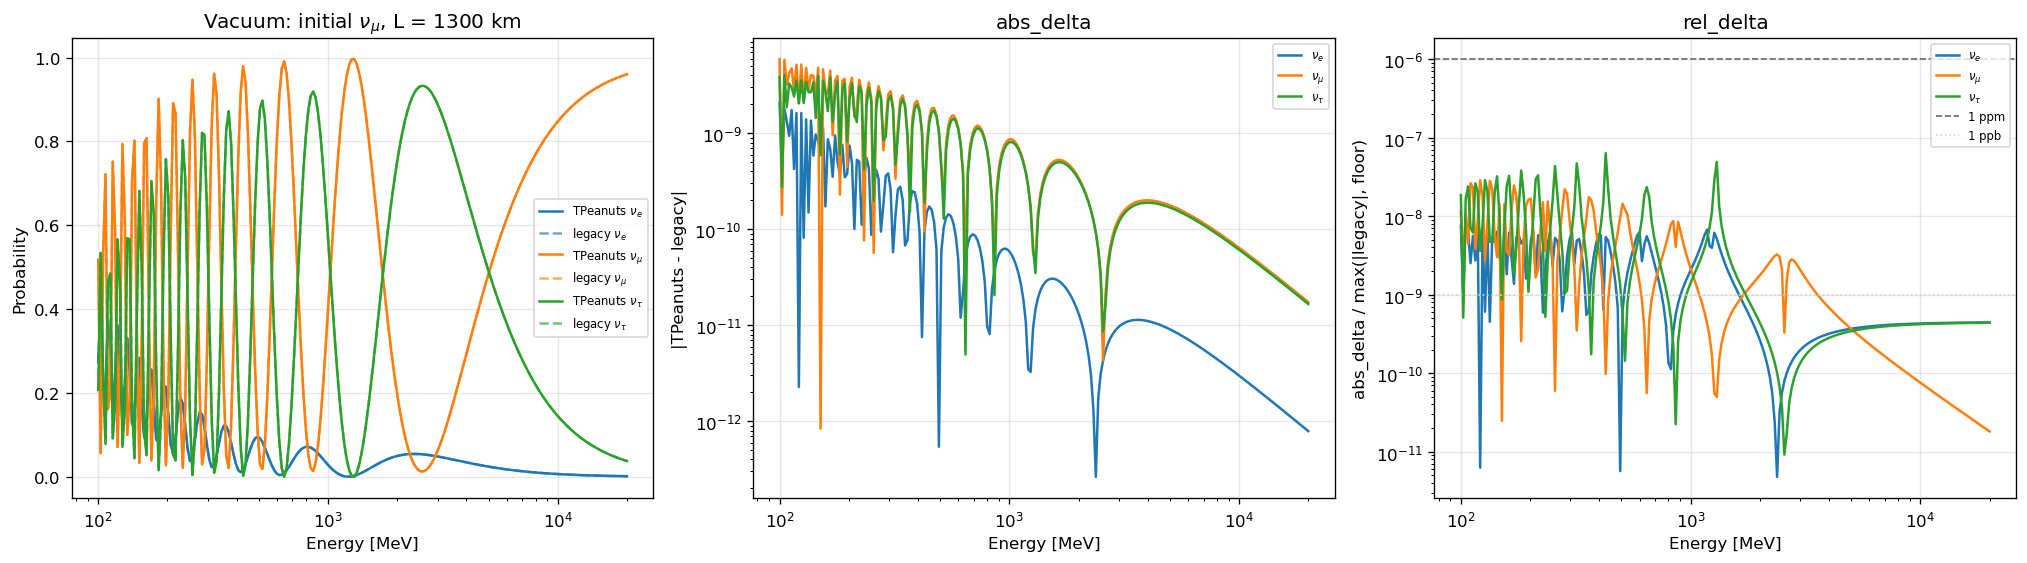

v:\output\validation\legacy\vacuum\validation_legacy1_vacuum_probability_scan.png


In [14]:

initial_state_t = FLAVOUR_STATES[VACUUM_PLOT_INITIAL_FLAVOUR]
P_t_vac = vacuum_probability_state(initial_state_t, oscillation, VACUUM_ENERGY_GRID_MEV, VACUUM_PLOT_BASELINE_KM, massbasis=False, context=context)
P_l_vac = np.stack([legacy_pvacuum(VACUUM_PLOT_INITIAL_STATE_NP, legacy_pmns, DM21_EV2, DM3L_EV2, float(E), VACUUM_PLOT_BASELINE_KM, massbasis=False) for E in to_numpy(VACUUM_ENERGY_GRID_MEV)])
plot_tripanel(VACUUM_ENERGY_GRID_MEV, P_t_vac, P_l_vac, title=rf"Vacuum: initial $\nu_\mu$, L = {VACUUM_PLOT_BASELINE_KM:.0f} km", xlabel="Energy [MeV]", filename="validation_legacy1_vacuum_probability_scan.png", output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS, xscale="log", quantity="probability")


## 5. Precision Mode Diagnostic

This diagnostic compares the full-precision default and the legacy-precision compatibility mode against the legacy Peanuts vacuum reference over the configured energy grid for the selected baseline and initial flavour. The panels show probability values, absolute differences, and relative differences.


,mode,L_km,initial_flavour,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,full_precision,1300.0,numu,660,5.929846e-09,1.616283e-10,6.426499e-10,6.350404e-08,8.438901e-10,3.638332e-09,0.000212,0.187752
1,legacy_precision,1300.0,numu,660,5.929846e-09,1.616283e-10,6.426499e-10,6.350404e-08,8.438901e-10,3.638332e-09,0.000212,0.187752


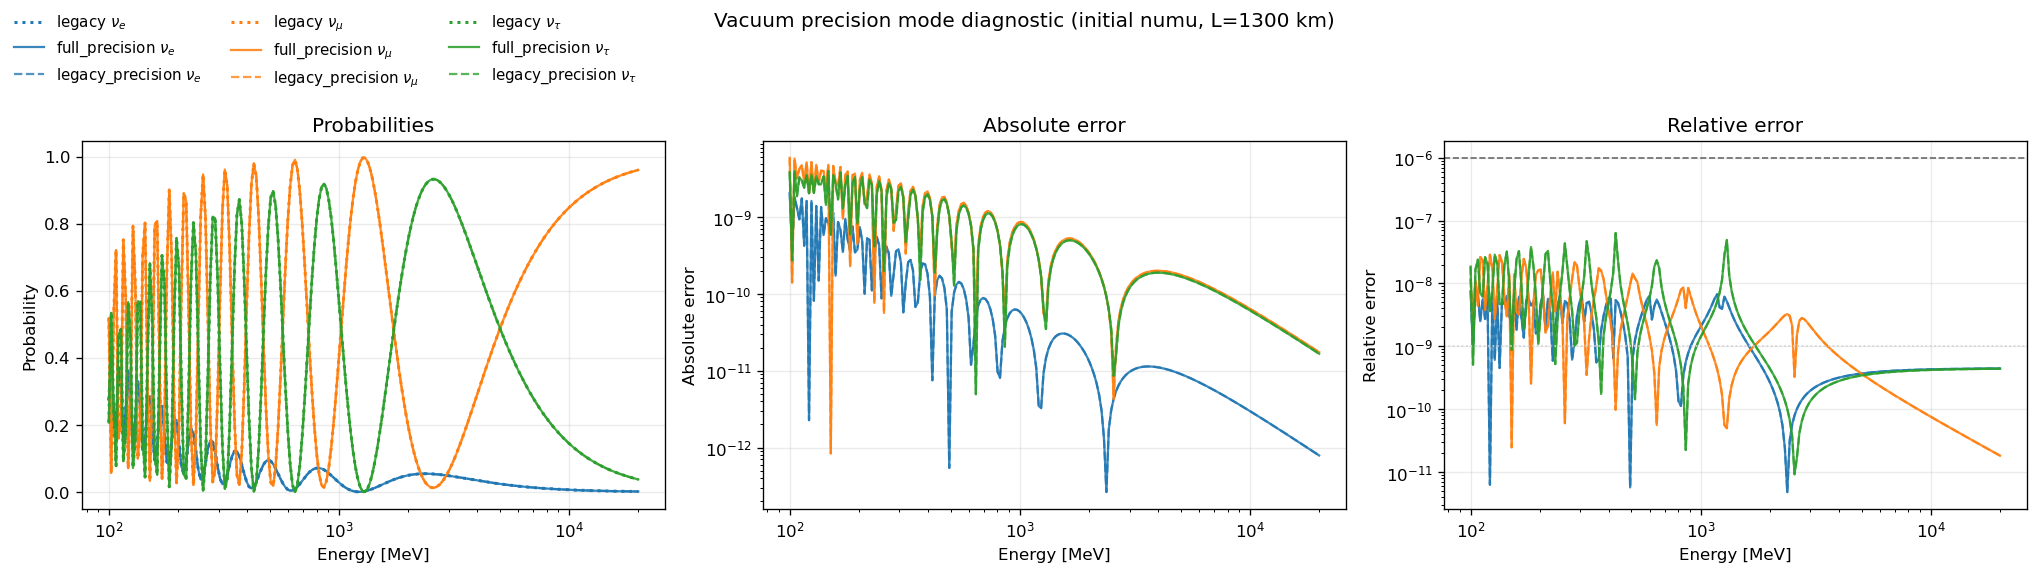

v:\output\validation\legacy\vacuum\validation_legacy1_vacuum_precision_modes_energy_scan.png


In [15]:
precision_modes = [("full_precision", False), ("legacy_precision", True)]
precision_energy_np = to_numpy(VACUUM_ENERGY_GRID_MEV)
precision_initial_state_t = FLAVOUR_STATES[VACUUM_PLOT_INITIAL_FLAVOUR]
precision_reference = np.stack([
    legacy_pvacuum(
        VACUUM_PLOT_INITIAL_STATE_NP,
        legacy_pmns,
        DM21_EV2,
        DM3L_EV2,
        float(energy),
        VACUUM_PLOT_BASELINE_KM,
        massbasis=False,
    )
    for energy in precision_energy_np
])

precision_rows = []
precision_scan_by_mode = {}
for mode_name, mode_flag in precision_modes:
    candidate_scan = vacuum_probability_state(
        precision_initial_state_t,
        oscillation,
        VACUUM_ENERGY_GRID_MEV,
        VACUUM_PLOT_BASELINE_KM,
        massbasis=False,
        context=context,
        legacy_precision=mode_flag,
    )
    precision_scan_by_mode[mode_name] = candidate_scan
    abs_delta, rel_delta = abs_rel_delta(candidate_scan, precision_reference)
    candidate_np = to_numpy(candidate_scan)
    for i, energy in enumerate(precision_energy_np):
        for final_name, alpha in FLAVOUR_INDEX.items():
            precision_rows.append(
                {
                    "medium": "vacuum",
                    "observable": "pvacuum_precision_mode",
                    "E_MeV": energy,
                    "L_km": VACUUM_PLOT_BASELINE_KM,
                    "initial_flavour": VACUUM_PLOT_INITIAL_FLAVOUR,
                    "mode": mode_name,
                    "final_flavour": final_name,
                    "candidate": candidate_np[i, alpha],
                    "reference": precision_reference[i, alpha],
                    "abs_delta": abs_delta[i, alpha],
                    "rel_delta": rel_delta[i, alpha],
                    "legacy_precision": mode_flag,
                }
            )
precision_mode_table = pd.DataFrame(precision_rows)
precision_mode_summary = summarize_validation(precision_mode_table, ["mode", "L_km", "initial_flavour"])
display(precision_mode_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True)
mode_styles = {"full_precision": "-", "legacy_precision": "--"}
mode_alphas = {"full_precision": 0.88, "legacy_precision": 0.78}
value_floor = 1.0e-300

for final_name, alpha in FLAVOUR_INDEX.items():
    label = FLAVOUR_LABELS[alpha]
    color = FLAVOUR_COLORS[alpha]
    axes[0].plot(precision_energy_np, precision_reference[:, alpha], color=color, linestyle=":", linewidth=1.8, label=f"legacy {label}")
    for mode_name, _ in precision_modes:
        candidate_scan = precision_scan_by_mode[mode_name]
        candidate_np = to_numpy(candidate_scan)
        abs_delta, rel_delta = abs_rel_delta(candidate_scan, precision_reference)
        axes[0].plot(precision_energy_np, candidate_np[:, alpha], color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")
        axes[1].semilogy(precision_energy_np, np.maximum(abs_delta[:, alpha], value_floor), color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")
        axes[2].semilogy(precision_energy_np, np.maximum(rel_delta[:, alpha], value_floor), color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")

axes[0].set_title("Probabilities")
axes[1].set_title("Absolute error")
axes[2].set_title("Relative error")
axes[0].set_ylabel("Probability")
axes[1].set_ylabel("Absolute error")
axes[2].set_ylabel("Relative error")
add_tolerance_lines(axes[2])
for ax in axes:
    ax.set_xlabel("Energy [MeV]")
    ax.set_xscale("log")
    ax.grid(alpha=0.25)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=3, fontsize=9, frameon=False)
fig.suptitle(f"Vacuum precision mode diagnostic (initial numu, L={VACUUM_PLOT_BASELINE_KM:.0f} km)", y=1.03)
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_and_show(
    "validation_legacy1_vacuum_precision_modes_energy_scan.png",
    fig,
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)


## 6. Vacuum Flux Propagation

This section validates TPeanuts' incoherent flux-propagation routine against its legacy counterpart. A synthetic atmospheric-like three-flavour flux $\Phi_\beta(E)$ is defined as

$$\Phi_\beta(E) = N_\beta \left(\frac{E}{E_0}\right)^{-\gamma_\beta}\!\!\exp\!\left(-\frac{E}{E_{c,\beta}}\right)$$

with spectral indices $\gamma \approx 2.0$–$2.15$ and exponential cutoffs at 50–70 GeV, mimicking the atmospheric flux at energies relevant for long-baseline detectors. The propagated final-state flux is

$$\Phi_\alpha^\text{out}(E) = \sum_\beta P(\nu_\beta \to \nu_\alpha;\,E,\,L)\,\Phi_\beta^\text{in}(E)$$

which in matrix form reads $\boldsymbol\Phi^\text{out} = P(E,L)\,\boldsymbol\Phi^\text{in}$. This tests not only the individual probability matrix elements but also the correctness of the matrix–vector contraction in the TPeanuts and legacy implementations.

**Expected Results:** 
- The relative flux difference $\delta_\text{rel}(\Phi_\alpha)$ should remain below 1 ppm for all flavours and energies, reflecting the same level of precision as the underlying oscillation probabilities.
- Small increases at the tails of the energy distribution (where the flux is exponentially suppressed) are expected due to the floor $\epsilon_\text{floor}$ in the relative-error computation.


,medium,observable,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,vacuum,flux,660,0.000135,1.207915e-08,0.000005,1.130627e-08,3.118385e-10,1.469068e-09,0.041855,44.523227


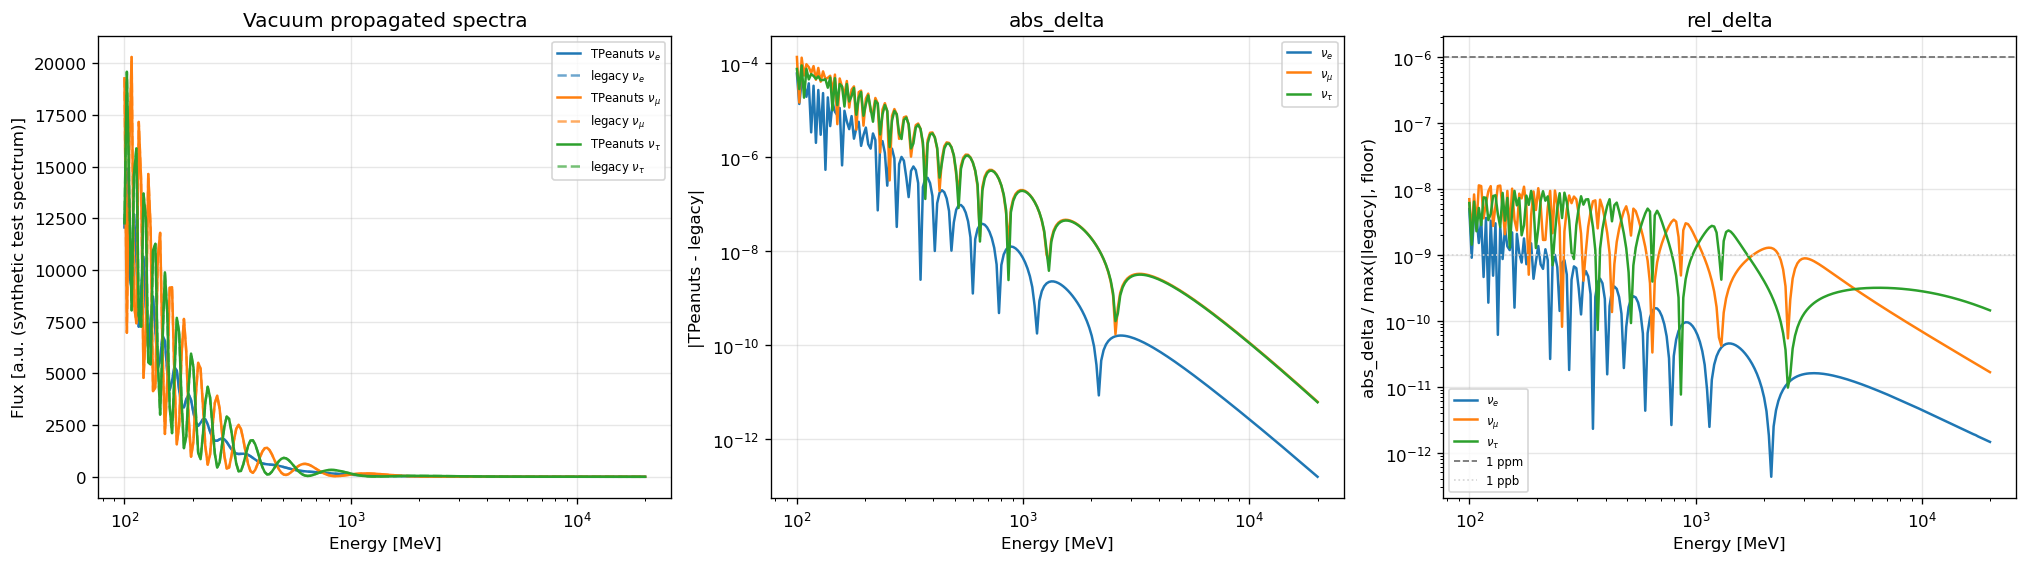

v:\output\validation\legacy\vacuum\validation_legacy1_vacuum_flux_scan.png


In [16]:

def synthetic_flux(E_MeV: torch.Tensor) -> torch.Tensor:
    x = E_MeV / 1000.0
    return torch.stack([
        1.00e2 * x.pow(-2.15) * torch.exp(-E_MeV / 5.0e4),
        2.50e2 * x.pow(-2.05) * torch.exp(-E_MeV / 6.0e4),
        1.50e1 * x.pow(-2.00) * torch.exp(-E_MeV / 7.0e4),
    ], dim=-1)

def legacy_vacuum_probability_matrix(energies_MeV, baseline_km):
    matrix = np.empty((len(to_numpy(energies_MeV)), 3, 3), dtype=float)
    for i, energy in enumerate(to_numpy(energies_MeV)):
        for beta in range(3):
            matrix[i, :, beta] = legacy_pvacuum(np.eye(3)[beta], legacy_pmns, DM21_EV2, DM3L_EV2, float(energy), float(baseline_km), massbasis=False)
    return matrix

vacuum_flux_in = synthetic_flux(VACUUM_ENERGY_GRID_MEV)
P_t_matrix = vacuum_probability_transition(oscillation, VACUUM_ENERGY_GRID_MEV, VACUUM_PLOT_BASELINE_KM, context=context)
P_l_matrix = legacy_vacuum_probability_matrix(VACUUM_ENERGY_GRID_MEV, VACUUM_PLOT_BASELINE_KM)
vacuum_flux_t = probability_incoherent(P_t_matrix, vacuum_flux_in)
vacuum_flux_l = np.einsum("eba,ea->eb", P_l_matrix, to_numpy(vacuum_flux_in))
abs_flux, rel_flux = abs_rel_delta(vacuum_flux_t, vacuum_flux_l)
flux_rows = []
for i, energy in enumerate(to_numpy(VACUUM_ENERGY_GRID_MEV)):
    for final_name, alpha in FLAVOUR_INDEX.items():
        flux_rows.append({"medium": "vacuum", "observable": "flux", "E_MeV": energy, "final_flavour": final_name, "candidate": to_numpy(vacuum_flux_t)[i, alpha], "reference": vacuum_flux_l[i, alpha], "abs_delta": abs_flux[i, alpha], "rel_delta": rel_flux[i, alpha]})
vacuum_flux_table = pd.DataFrame(flux_rows)
display(summarize_validation(vacuum_flux_table, ["medium", "observable"]))
plot_tripanel(VACUUM_ENERGY_GRID_MEV, vacuum_flux_t, vacuum_flux_l, title="Vacuum propagated spectra", xlabel="Energy [MeV]", filename="validation_legacy1_vacuum_flux_scan.png", output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS, xscale="log", quantity="flux", flux_units="a.u. (synthetic test spectrum)")


## 7. Export Results

All validation data are written to disk as CSV files for consumption by `validation_legacy0_summary.ipynb` and for archival purposes:

- `validation_legacy1_vacuum_probability.csv` - full grid of per-row probability values with `abs_delta` and `rel_delta` columns.
- `validation_legacy1_vacuum_probability_summary.csv` - summary statistics (max, median, mean) grouped by baseline and initial flavour.
- `validation_legacy1_vacuum_precision_modes.csv` - full energy-grid comparison between full precision and legacy precision.
- `validation_legacy1_vacuum_precision_modes_summary.csv` - grouped summary of the precision-mode deltas.
- `validation_legacy1_vacuum_flux.csv` - flux-propagation comparison across the dense energy grid.


In [17]:

vacuum_probability_table.to_csv(OUTPUT_DIR / "validation_legacy1_vacuum_probability.csv", index=False)
vacuum_probability_summary.to_csv(OUTPUT_DIR / "validation_legacy1_vacuum_probability_summary.csv", index=False)
#precision_mode_table.to_csv(OUTPUT_DIR / "validation_legacy1_vacuum_precision_modes.csv", index=False)
#precision_mode_summary.to_csv(OUTPUT_DIR / "validation_legacy1_vacuum_precision_modes_summary.csv", index=False)
vacuum_flux_table.to_csv(OUTPUT_DIR / "validation_legacy1_vacuum_flux.csv", index=False)
print(OUTPUT_DIR)


v:\output\validation\legacy\vacuum


## 8. Summary

The final table collects the maximum and median relative differences from the probability, precision-mode, and flux validations. It is generated from the computed DataFrames above so it always reflects the current notebook parameters.

In [18]:
summary_tables = [
    ("vacuum probability", vacuum_probability_table),
    ("precision modes", precision_mode_table),
    ("vacuum flux", vacuum_flux_table),
]
summary_rows = []
for label, table in summary_tables:
    summary_rows.append({
        "check": label,
        "rows": len(table),
        "max_abs_delta": table["abs_delta"].max(),
        "max_rel_delta": table["rel_delta"].max(),
        "median_rel_delta": table["rel_delta"].median(),
        "status": status_from_rel(table["rel_delta"].max()),
    })
validation_summary = pd.DataFrame(summary_rows)
display(validation_summary)
print("Vacuum validation is expected to be limited by floating-point round-off; legacy_precision does not alter vacuum propagation.")

,check,rows,max_abs_delta,max_rel_delta,median_rel_delta,status
0,vacuum probability,144,2.099017e-08,1.508180e-07,4.463993e-10,PASS < ppm
1,precision modes,1320,5.929846e-09,6.350404e-08,8.438901e-10,PASS < ppm
2,vacuum flux,660,1.345001e-04,1.130627e-08,3.118385e-10,PASS < ppm


Vacuum validation is expected to be limited by floating-point round-off; legacy_precision does not alter vacuum propagation.
